In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("vendas.csv")

In [12]:
df_limpo = df.copy()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_venda       100 non-null    int64  
 1   data_venda     100 non-null    object 
 2   cliente        100 non-null    object 
 3   idade_cliente  97 non-null     float64
 4   categoria      97 non-null     object 
 5   produto        100 non-null    object 
 6   regiao         100 non-null    object 
 7   quantidade     100 non-null    int64  
 8   valor_venda    99 non-null     float64
 9   cancelado      100 non-null    object 
dtypes: float64(2), int64(2), object(6)
memory usage: 7.9+ KB


In [4]:
df.head()

,id_venda,data_venda,cliente,idade_cliente,categoria,produto,regiao,quantidade,valor_venda,cancelado
0,1,2025-01-29,Daniela,32.0,Acessórios,Carregador,Norte,9,3720.67,Sim
1,2,2025-04-19,Daniela,32.0,Acessorios,Fone,Sul,4,197.50,Não
2,3,04-25-2025,Ana,66.0,Informatica,Notebook,Sudeste,6,1427.04,Não
3,4,25/02/2025,Gustavo,24.0,Informatica,Mouse,Centro-Oeste,10,555.94,Não
4,5,04-28-2025,Gustavo,23.0,Eletrônicos,Smartwatch,Sul,6,667.89,Sim


In [5]:
df.isnull().sum()

,0
id_venda,0
data_venda,0
cliente,0
idade_cliente,3
categoria,3
produto,0
regiao,0
quantidade,0
valor_venda,1
cancelado,0


In [6]:
df["idade_cliente"] = (
    df["idade_cliente"]
    .fillna(df["idade_cliente"].median())
)

In [7]:
df.isnull().sum()

,0
id_venda,0
data_venda,0
cliente,0
idade_cliente,0
categoria,3
produto,0
regiao,0
quantidade,0
valor_venda,1
cancelado,0


In [8]:
df["categoria"].unique()

array(['Acessórios', 'Acessorios', 'Informatica', 'Eletrônicos',
       'Celulares', nan, 'Informática'], dtype=object)

In [9]:
df["categoria"] = df["categoria"].replace({
    "Informatica": "Informática",
    "Acessorios": "Acessórios"
})

In [10]:
df["categoria"].unique()

array(['Acessórios', 'Informática', 'Eletrônicos', 'Celulares', nan],
      dtype=object)

In [13]:
df["categoria"] = (
    df["categoria"]
    .fillna("Não informado")
)

In [14]:
df["categoria"].unique()

array(['Acessórios', 'Informática', 'Eletrônicos', 'Celulares',
       'Não informado'], dtype=object)

In [15]:
df["categoria"].value_counts()

,count
categoria,
Acessórios,34
Informática,26
Celulares,21
Eletrônicos,16
Não informado,3


In [16]:
df.duplicated().sum()

np.int64(2)

In [17]:
df = df.drop_duplicates()

In [18]:
df.shape

(98, 10)

In [19]:
df["data_venda"] = pd.to_datetime(
    df["data_venda"],
    format="mixed",
    dayfirst=True
)

In [20]:
df["mes"] = df["data_venda"].dt.month
df["ano"] = df["data_venda"].dt.year

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98 entries, 0 to 99
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id_venda       98 non-null     int64         
 1   data_venda     98 non-null     datetime64[ns]
 2   cliente        98 non-null     object        
 3   idade_cliente  98 non-null     float64       
 4   categoria      98 non-null     object        
 5   produto        98 non-null     object        
 6   regiao         98 non-null     object        
 7   quantidade     98 non-null     int64         
 8   valor_venda    97 non-null     float64       
 9   cancelado      98 non-null     object        
 10  mes            98 non-null     int32         
 11  ano            98 non-null     int32         
dtypes: datetime64[ns](1), float64(2), int32(2), int64(2), object(5)
memory usage: 9.2+ KB


In [23]:
df[df["valor_venda"] < 0]

,id_venda,data_venda,cliente,idade_cliente,categoria,produto,regiao,quantidade,valor_venda,cancelado,mes,ano
30,31,2025-03-09,Eduardo,47.0,Informática,Mouse,Norte,1,-150.0,Não,3,2025


In [24]:
Q1 = df["valor_venda"].quantile(0.25)
Q3 = df["valor_venda"].quantile(0.75)

IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

df[df["valor_venda"] > limite_superior]

,id_venda,data_venda,cliente,idade_cliente,categoria,produto,regiao,quantidade,valor_venda,cancelado,mes,ano
14,15,2025-10-05,Carlos,52.0,Acessórios,Carregador,Sul,6,50000.0,Não,10,2025
44,45,2025-03-26,Eduardo,50.0,Acessórios,Fone Bluetooth,Sudeste,6,25000.0,Não,3,2025
84,85,2025-02-06,Eduardo,46.0,Informática,Notebook,Sudeste,5,50000.0,Não,2,2025


In [25]:
faixas = [
    0, 500, 2000, 10000, 100000
]

rotulos = [
    "Baixa",
    "Média",
    "Alta",
    "Premium"
]

df_limpo["categoria_venda"] = pd.cut(
    df_limpo["valor_venda"],
    bins=faixas,
    labels=rotulos
)

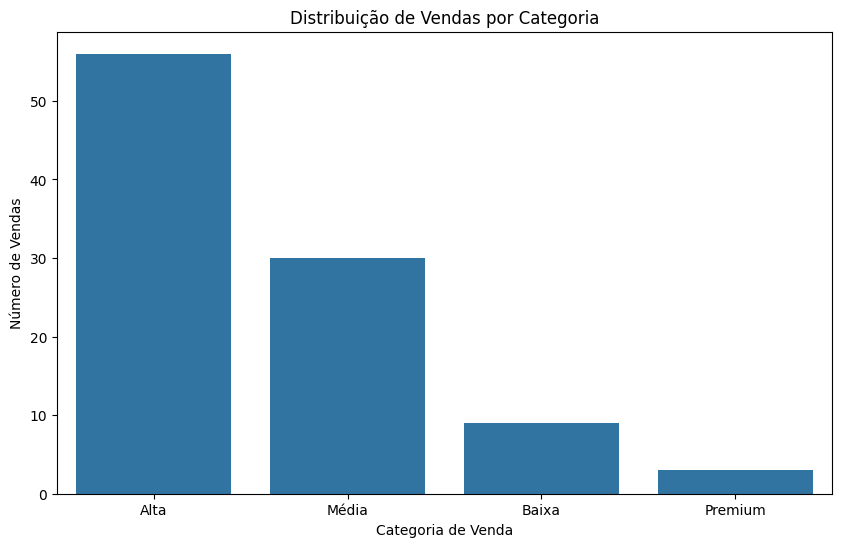

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=df_limpo, x='categoria_venda', order=df_limpo['categoria_venda'].value_counts().index)
plt.title('Distribuição de Vendas por Categoria')
plt.xlabel('Categoria de Venda')
plt.ylabel('Número de Vendas')
plt.show()

In [28]:
faturamento_total = (
    df_limpo["valor_venda"]
    .sum()
)

ticket_medio = (
    df_limpo["valor_venda"]
    .mean()
)

quantidade_vendas = (
    df_limpo.shape[0]
)

### Análise das Métricas de Vendas

In [29]:
print(f"Faturamento Total: R$ {faturamento_total:,.2f}")
print(f"Ticket Médio: R$ {ticket_medio:,.2f}")
print(f"Quantidade de Vendas: {quantidade_vendas}")

Faturamento Total: R$ 367,954.62
Ticket Médio: R$ 3,716.71
Quantidade de Vendas: 100
